In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [2]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

print("Train dir:", train_dir.resolve())
print("Test dir:", test_dir.resolve())
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

#probati kasnije sa većim dimenzijama slike (128, 224) - bilo je značajno sporije izvršavanje
IMG_SIZE = 64 
BATCH_SIZE = 32
#probale smo manji broj epoha za početna testiranja i postepeno povećavale da proverimo da li dolazi do preprilagođavanja
EPOCHS = 20
LEARNING_RATE = 0.001
#probale smo DROPOUT_RATE = 0.5, ali je 0.3 dalo bolje rezultate (manji loss i veći accuracy na istom broju epoha)
DROPOUT_RATE = 0.3
VALIDATION_SPLIT = 0.2
SEED = 42

#na Windows-u na cpu je bilo znatno sporije treniranje (oko 12 epoha za 40 minuta :()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train dir: C:\Users\HS\Documents\GitHub\ML_projekat\data\tomatoleaf\tomato\train
Test dir: C:\Users\HS\Documents\GitHub\ML_projekat\data\tomatoleaf\tomato\val
Train exists: True
Test exists: True
Device: cpu


#### TRANSFORMACIJE SLIKA

CNN očekuje ulaz oblika (batch_size, channels, height, width). Koristimo ToTensor() koji pretvara sliku u tensor i automatski skalira piksele iz opsega 0-255 u 0-1. U Normalize() prosleđujemo standardnu normalizaciju često korišćenu za RGB slike. Takođe, zbog problema sa putanjama na Windows-u, dodajemo funkcije add_windows_long_path_prefix(path) i pil_loader_safe(path) (objašnjenje u komentarima).

In [3]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() moze da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogucava citanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraca obicnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
full_train_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=transform,
    loader=pil_loader_safe
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=transform,
    loader=pil_loader_safe
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(full_train_dataset))
print("Broj slika u test skupu:", len(test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10001
Broj slika u test skupu: 1000


#### PODELA TRAIN SKUPA NA TRAIN I VALIDACIONI SKUP

Pošto poseban test skup nije dostupan, ideja je da koristimo originalni validacioni skup kao test skup za finalnu evaluaciju. Za validaciju tokom treniranja izdvajamo deo originalnog trening skupa.

In [5]:
val_size = int(len(full_train_dataset) * VALIDATION_SPLIT)
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8001
Validation size: 2000
Test size: 1000


#### PRAVIMO DATALOADERE

Probati sa num_workers = 2 ili num_workers = 4, ukoliko sistem podržava za brže izvršavanje.

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

#### MODEL

Umesto velikog Flatten sloja koristmo AdaptiveAvgPool2d, koji svaku mapu karakteristika svodi na jednu vrednost. Time se smanjuje broj parametara u klasifikacionom delu modela i ubrzava treniranje, što nam je zgodno za baseline CNN model. Napomena: Sa Flatten verzijom iz prethodnog commit-a, izlaz prve epohe se nije pojavio ni nakon 2 sata.

In [7]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)
        x = self.fc(x)

        return x

In [8]:
model = BaselineCNN(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

print(model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

#### FUNKCIJA ZA TRENIRANJE JEDNE EPOHE

In [10]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total_loss += loss.item() * images.size(0)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

#### FUNKCIJA EVALUACIJE NA TEST SKUPU

In [11]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy, all_labels, all_predictions

#### TRENIRANJE

In [12]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = np.inf
best_val_acc = 0.0
best_epoch = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_epoch = epoch + 1

        # Cuvamo najbolji model u memoriji, bez pisanja na disk u svakoj epohi.
        best_model_state = copy.deepcopy(model.state_dict())

        print(
            f"  -> Novi najbolji model "
            f"(epoch {best_epoch}, val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.4f})"
        )

print("\nTreniranje završeno.")
print(f"Najbolji model je iz epohe {best_epoch}")
print(f"Najbolji val_loss: {best_val_loss:.4f}")
print(f"Val_acc tog modela: {best_val_acc:.4f}")

# Vracamo najbolje tezine u model i cuvamo ih jednom na disk.
best_model_path = "baseline_cnn_best.pth"

if best_model_state is None:
    raise RuntimeError("Najbolji model nije sacuvan. Proveri trening petlju.")

model.load_state_dict(best_model_state)
model.to(device)
model.eval()

torch.save(model.state_dict(), best_model_path)
print(f"Najbolji model je sačuvan u: {best_model_path}")

Epoch [1/20] Train loss: 1.6557, Train acc: 0.4024 | Val loss: 1.1122, Val acc: 0.6360
  -> Novi najbolji model (epoch 1, val_loss=1.1122, val_acc=0.6360)
Epoch [2/20] Train loss: 1.0238, Train acc: 0.6390 | Val loss: 0.8717, Val acc: 0.7105
  -> Novi najbolji model (epoch 2, val_loss=0.8717, val_acc=0.7105)
Epoch [3/20] Train loss: 0.8372, Train acc: 0.6978 | Val loss: 0.7346, Val acc: 0.7595
  -> Novi najbolji model (epoch 3, val_loss=0.7346, val_acc=0.7595)
Epoch [4/20] Train loss: 0.7250, Train acc: 0.7518 | Val loss: 0.6739, Val acc: 0.7755
  -> Novi najbolji model (epoch 4, val_loss=0.6739, val_acc=0.7755)
Epoch [5/20] Train loss: 0.6479, Train acc: 0.7822 | Val loss: 0.6464, Val acc: 0.7875
  -> Novi najbolji model (epoch 5, val_loss=0.6464, val_acc=0.7875)
Epoch [6/20] Train loss: 0.5849, Train acc: 0.8013 | Val loss: 0.5222, Val acc: 0.8205
  -> Novi najbolji model (epoch 6, val_loss=0.5222, val_acc=0.8205)
Epoch [7/20] Train loss: 0.5318, Train acc: 0.8238 | Val loss: 0.5063,

#### GRAFICI

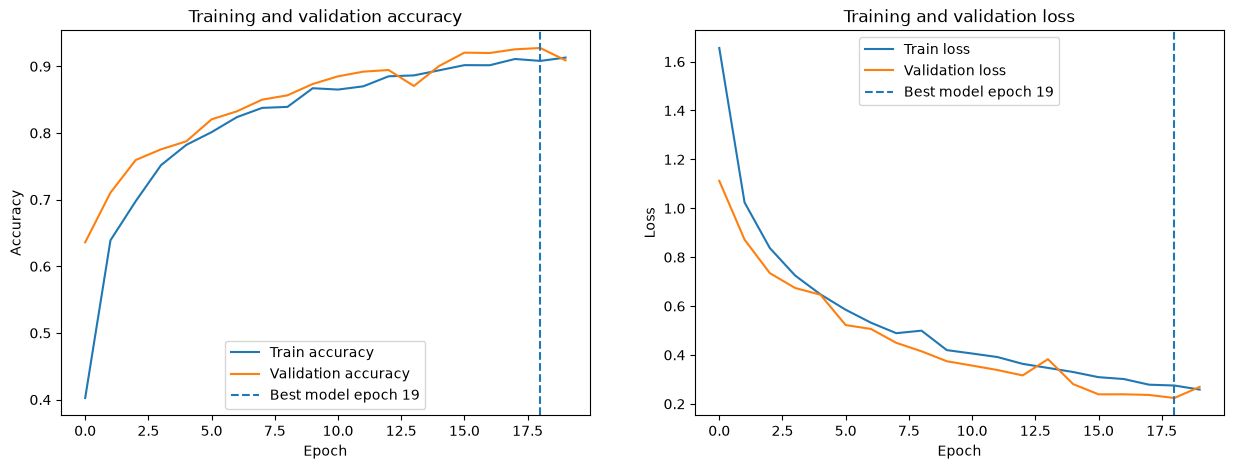

In [13]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="Train accuracy")
plt.plot(history["val_acc"], label="Validation accuracy")
plt.axvline(best_epoch - 1, linestyle="--", label=f"Best model epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.axvline(best_epoch - 1, linestyle="--", label=f"Best model epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

#### EVALUACIJA NAJBOLJEG MODELA NA TEST SKUPU

Baseline CNN model sa tri konvoluciona sloja, global average pooling slojem i dropout regularizacijom postigao je test tačnost od 92.4%. Vidimo da model pokazuje stabilno učenje, jer trening i validacioni gubitak opadaju kroz epohe, dok tačnost raste. Najbolje se klasifikuju zdravi listovi i klasa Tomato mosaic virus, dok se najviše grešaka javlja između vizuelno sličnih bolesti, kao što su Early blight, Late blight, Leaf Mold i Spider mites/Target Spot.

In [14]:
test_loss, test_acc, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.2764
Test accuracy: 0.9230


#### PRECISION, RECALL, F1-SCORE

Pošto su klase balansirane, macro avg i weighted avg su isti.
Najbolje klase su:

Tomato___healthy
precision 0.99, recall 1.00, f1-score 1.00

Tomato___Tomato_mosaic_virus
precision 0.97, recall 0.99, f1-score 0.98

Tomato___Bacterial_spot
precision 0.92, recall 0.97, f1-score 0.94

Najslabija, ali i dalje solidna klasa je:

Tomato___Late_blight
precision 0.83, recall 0.86, f1-score 0.85

To znači da se Late_blight najviše meša sa nekim drugim bolestima.

In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.96      0.93      0.94       100
                        Tomato___Early_blight       0.84      0.87      0.86       100
                         Tomato___Late_blight       0.82      0.90      0.86       100
                           Tomato___Leaf_Mold       0.94      0.85      0.89       100
                  Tomato___Septoria_leaf_spot       0.96      0.85      0.90       100
Tomato___Spider_mites Two-spotted_spider_mite       0.92      0.91      0.91       100
                         Tomato___Target_Spot       0.94      0.96      0.95       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.89      0.96      0.92       100
                 Tomato___Tomato_mosaic_virus       0.99      1.00      1.00       100
                             Tomato___healthy       0.99      1.00      1.00       100

                                     accu

#### MATRICA KONFUZIJE

Matrica konfuzije pokazuje da model dobro razlikuje većinu klasa.

Na dijagonali su tačne klasifikacije:

Bacterial_spot: 97/100  
Early_blight: 88/100  
Late_blight: 86/100  
Leaf_Mold: 88/100  
Septoria_leaf_spot: 93/100  
Spider_mites: 90/100  
Target_Spot: 96/100  
Yellow_Leaf_Curl_Virus: 87/100  
Tomato_mosaic_virus: 99/100  
healthy: 100/100  

Najveće greške koje se vide:

Early_blight -> Late_blight: 7 slika  
Spider_mites -> Target_Spot: 8 slika  
Yellow_Leaf_Curl_Virus -> Spider_mites: 6 slika  
Leaf_Mold -> Late_blight: 5 slika  
Late_blight -> Early_blight: 5 slika  
Septoria_leaf_spot -> Late_blight: 4 slike  
Target_Spot -> Spider_mites: 4 slike  

Najbolje se klasifikuju zdravi listovi i klasa Tomato mosaic virus, dok se najviše grešaka javlja između vizuelno sličnih bolesti, kao što su Early blight, Late blight, Leaf Mold i Spider mites/Target Spot. Ovaj rezultat koristimo kao referentnu tačku za poređenje sa metric learning pristupom.

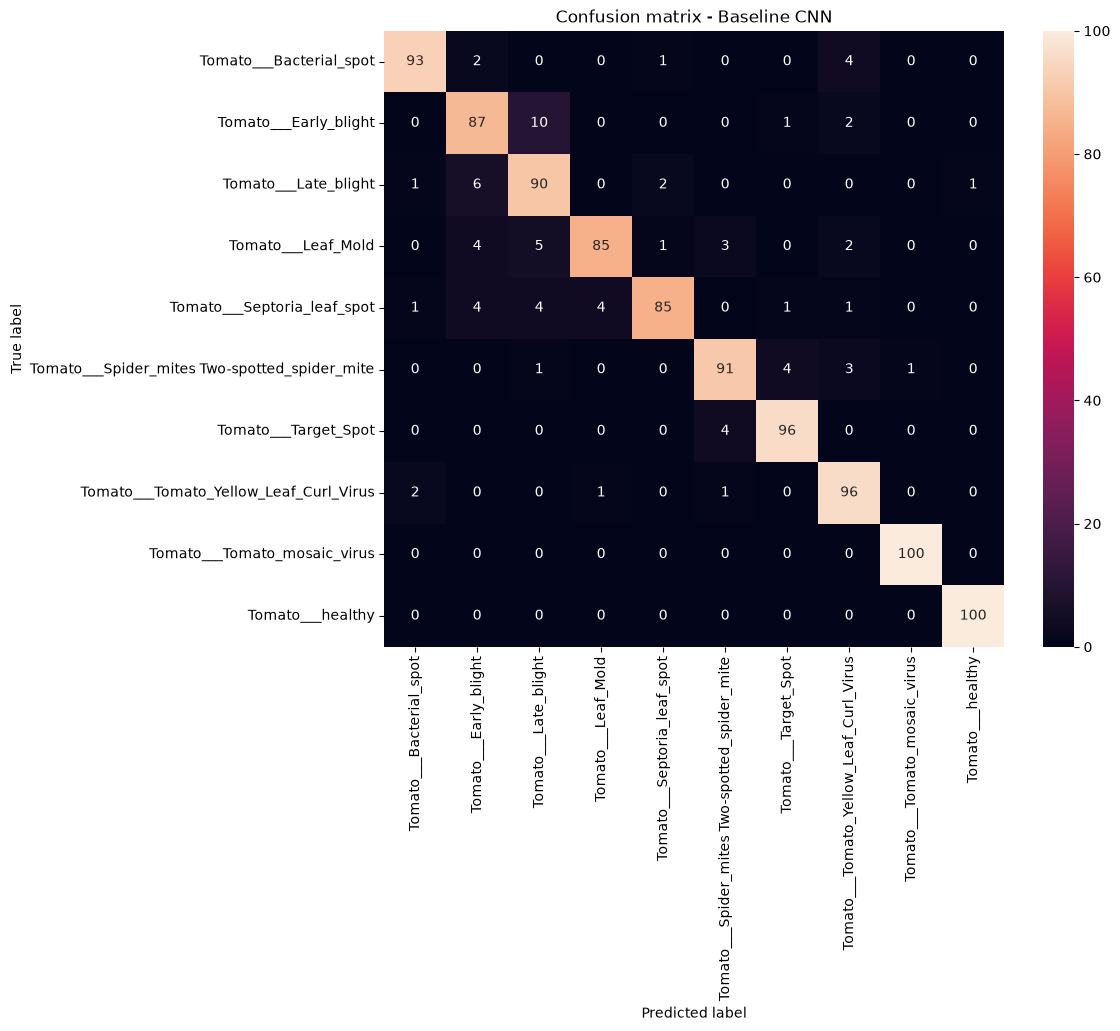

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Baseline CNN")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()